# Random Forest Training & Evaluation

In this notebook we present the training and evaluation of a Random Forest model on the preprocessed dataset of tennis matches, described previously in `src/notebooks/preprocessing.ipynb`. 

The document is structured as follows:
- **Setup & Imports**: we import the necessary libraries and modules, and build the preprocessing pipeline.
- **Training & Fine-tuning**: we train the model and perform hyperparameter tuning
- **Evaluation**: we evaluate the model on the test set and analyze the results.

# Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
    ]
)

# Training & Fine Tuning

Firstly, we add the Random Forest Classifier as a step for the pipeline, then the we perform the fine tuning of the hyperparameters using a `GridSearchCV` with 5-fold cross validation.  

In [ ]:
random_forest_train_pipeline = training_pipeline(model=RandomForestClassifier(random_state=42))

pipeline = Pipeline(
    steps = preprocessor.steps + random_forest_train_pipeline.steps
)

hyperparams = {
        'training__n_estimators': [100, 200, 300],
        'training__max_depth': [None, 10, 20],
        'training__min_samples_split': [2, 5, 10],
        'training__min_samples_leaf': [1, 2, 4]
    }

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=GridSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
    )

search_rf.fit(X_train, y_train)

We derive the best estimator from the search, and we validate the model using cross-validation on the training set.

In [4]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.676236
std      0.004319
min      0.671293
25%      0.674678
50%      0.676032
75%      0.676032
max      0.683142
dtype: float64


The classifier demonstrated moderate classification performance, achieving an average accuracy of 67% across five cross-validation folds. 
Its low standard deviation suggests that the model's performance is stable and relatively insensitive to the particular dataset on which it was trained.

## Feature Selection

The feature set generated after preprocessing contains many columns, some of which are redundant or weakly related to the target outcome. Thus, we can perform feature selection before the final Random Forest training, to improve generalization on unseen matches, reducing the noise and model complexity. 
Moreover, this method helps identify which tennis statistics are most informative for predicting the winner.

Initially, we extract the feature importance scores from the tuned Random Forest model. 

In [5]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train
)

importances

,importance
avg_bet_diff,0.203675
max_bet_diff,0.185960
weighted_ranking_diff,0.079166
pts_diff,0.071294
weighted_pts_diff,0.055813
...,...
Tournament_Mifel Open,0.000006
Tournament_Zhuhai Open,0.000004
Tournament_AEGON International,0.000003
Tournament_Emilia-Romagna Open,0.000000


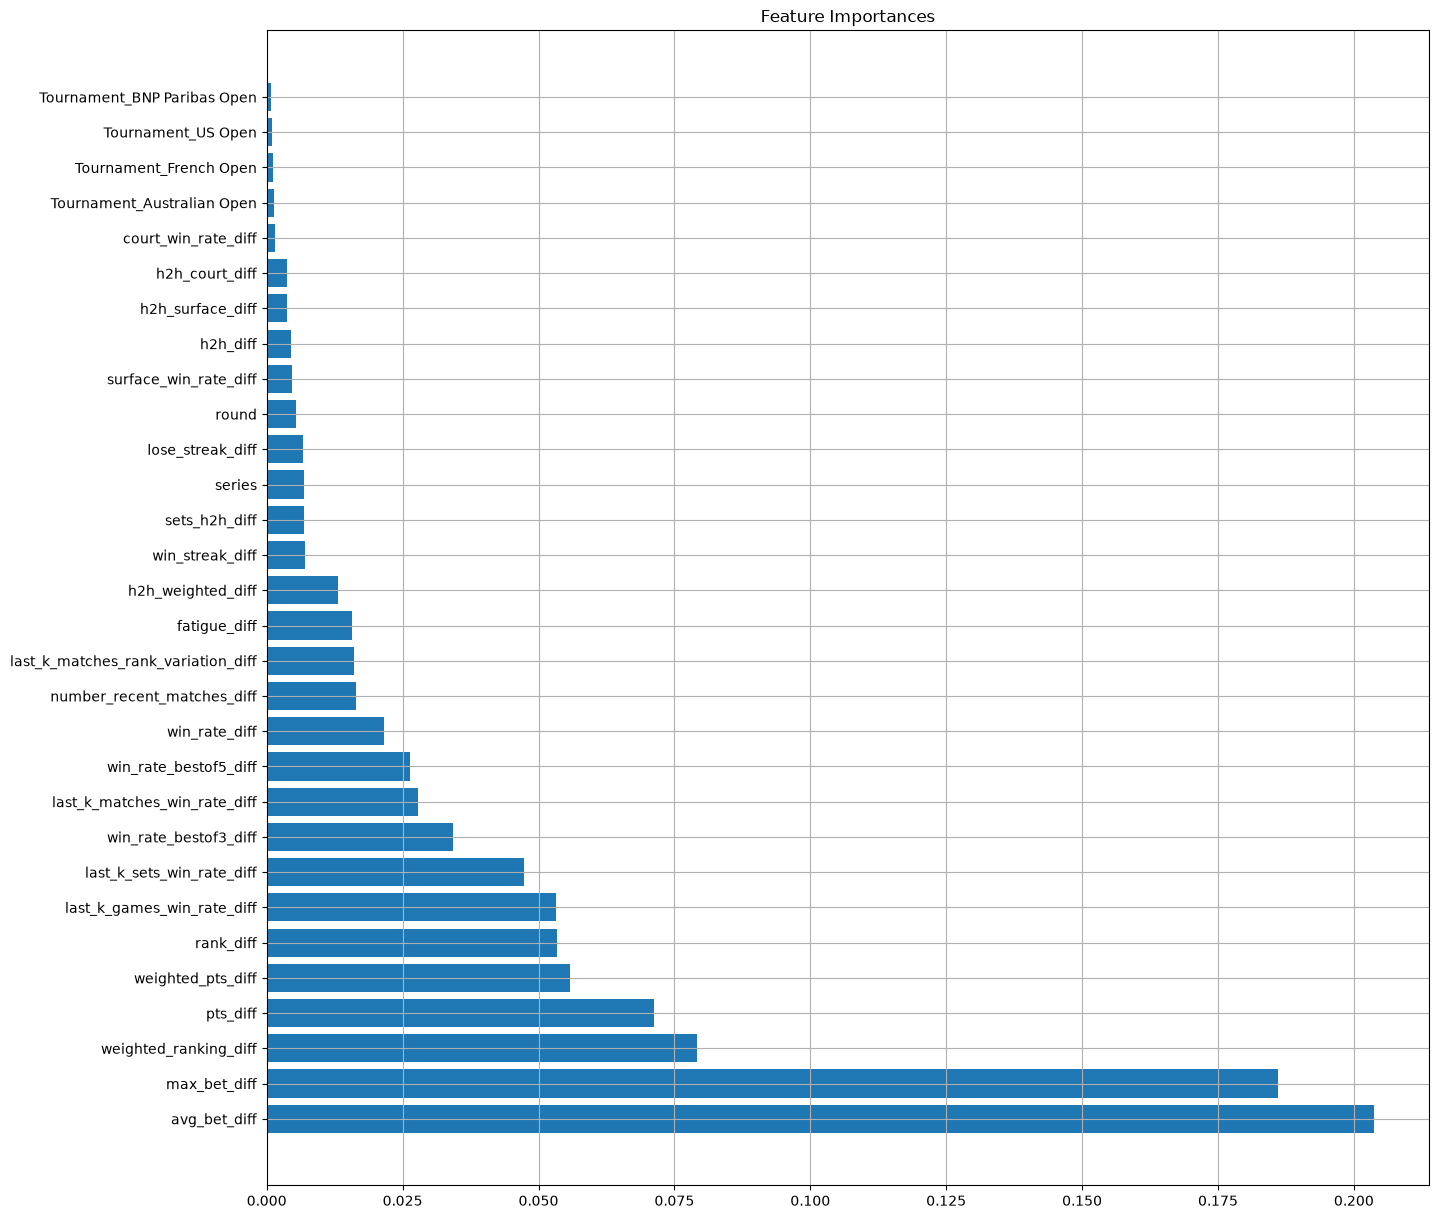

In [6]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=30
)

Since the tournament ohe features look like they to be not very informative, firstly, we try to remove them and see the model performance by adding a `DropFeatureSelector` step to the pipeline. Then, we perform the same procedure for validating the model performance.

In [ ]:
pipeline = Pipeline(
        steps= preprocessor.steps + [
            ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
            ] + random_forest_train_pipeline.steps
    )

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=GridSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
    )

search_rf.fit(X_train, y_train)

In [8]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.676439
std      0.007094
min      0.671970
25%      0.672309
50%      0.672309
75%      0.677048
max      0.688558
dtype: float64


In [9]:
len(feature_importance(pipeline=best_estimator, X=X_train))

26

The pipeline reduces the number of features to 26, and the best estimator of the search results still in a stable model, with slightly improved accuracy.

Now by adding a step for `RFECV` in the pipeline, we try to find the best subset of features for describing the target variable.

Here we use the `RandomizedSearchCV` method to find the best hyperparameters after subset selection.

In [10]:
rcevf_pipeline = feature_selection_pipeline(
    model=RandomForestClassifier(random_state=42),
    tscv=TSCV
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
                ("fs", rcevf_pipeline),
            ] + random_forest_train_pipeline.steps
    )

In [ ]:
search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_rf.fit(X_train, y_train)

In [12]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.675152
std      0.007561
min      0.670278
25%      0.671632
50%      0.672309
75%      0.672986
max      0.688558
dtype: float64


The accuracy of the model is similar to the previous one, then we can choose the model with less features.

Therefore we can construct and fit the full pipeline using the best estimator obtained from the search, and the `RFECV` step for feature selection.

In [13]:
full_pipeline_rf = best_estimator

# Evaluation

We evaluate the full pipeline on the test set.

In [14]:
y_pred = full_pipeline_rf.predict(X_test)

In [15]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6808

Roc Auc:
0.7405

F1:
0.6688

Recall:
0.6625

Confusion Matrix:
      0     1
0  1600   692
1   733  1439


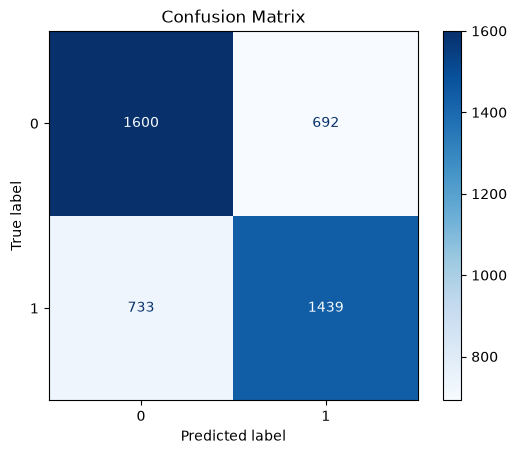

In [16]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

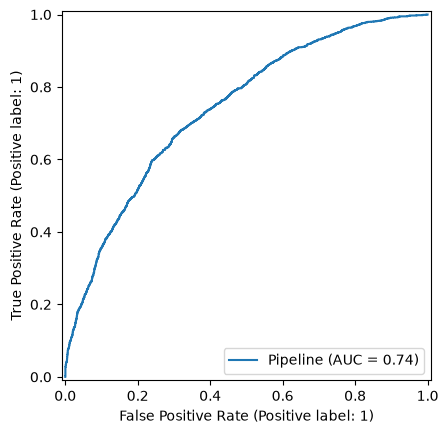

In [17]:
plot_roc_curve(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test
)

Recall that the task is a binary classification problem with two players, thus, the goal of the model should be to predict correctly the most amount of matches outcome.
Therefore the main metrics to evaluate the generalization of the model are accuracy and roc-auc:
- The accuracy of the model on unseen matches is around 0.68, which is similar to the accuracy obtained during validation.
- The roc-auc score obtained reached 0.74.
- The confusion matrix shows that the model does not favor any player, since the difference between the number of false positives and false negatives is not significant.

### Wrongly Predicted Matches

In conclusion, we investigate the distribution of wrongly predicted matches.

In [ ]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
X_test_transformed = full_pipeline_rf[:-1].transform(X_test)
errors = X_test_transformed[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]
# errors["proba_pos"] = full_pipeline_rf.predict_proba(X_test)[:, 1]

player2_wins_wrong_pred = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
player1_wins_wrong_pred = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

player2_wins_wrong_pred.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
round,692,2.24133,1.66287,0,1,2,2.25,7
series,692,1.44364,1.39505,0,0,1,2,4
pts_diff,692,890.988,1484.39,-6059,-26,471.5,1439.25,9655
weighted_pts_diff,692,2.70415e+10,1.01634e+11,-3.71005e+11,-2.26294e+07,1.07458e+09,1.17881e+10,1.28608e+12
rank_diff,692,-46.422,118.919,-875,-67.25,-28,2,861
weighted_ranking_diff,692,0.0730688,0.122078,-0.341886,-0.00237329,0.0436178,0.114228,0.850929
sets_h2h_diff,692,0.449422,2.49318,-15,0,0,1,15
win_rate_diff,692,-0.112159,0.31117,-1.64646,-0.291669,-0.106501,0.0564666,1.5
max_bet_diff,692,-1.67527,2.17606,-32.83,-2.1525,-1.08,-0.6275,1.18
avg_bet_diff,692,-1.45088,1.61228,-18.06,-1.9825,-0.99,-0.5675,1.05


The distribution of the incorrectly predicted matches, i.e., matches in which Player 2 was the actual winner, suggests that the model tends to misclassify these matches because the player_1 seems to have better statistics than player_2.

For example, considering the features in order of importance, we obtain the following median values:
- `player1_Max` < `player2_Max` $\rightarrow$ `max_bet_diff` < 0
- `player1_Avg` < `player2_Avg` $\rightarrow$ `avg_bet_diff` < 0
- `player1_Rank` < `player2_Rank` $\rightarrow$ `rank_diff` < 0
- `player1_Pts` > `player2_Pts` $\rightarrow$ `pts_diff` > 0

In [46]:
correct = X_test_transformed[~wrong].copy()
correct["y_true"] = np.asarray(y_test)[~wrong]
correct["y_pred"] = np.asarray(y_pred)[~wrong]

player2_wins_right_pred = correct[(correct.y_true == 0) & (correct.y_pred == 0)] # player_2 actually won
player1_wins_right_pred = correct[(correct.y_true == 1) & (correct.y_pred == 1)] # player_1 actually won

player2_wins_right_pred.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
round,1600,2.27312,1.61211,0,1,2,3,7
series,1600,1.57625,1.47158,0,0,1,2,4
pts_diff,1600,-1387.33,2104.26,-11600,-2039.75,-719,-79,5535
weighted_pts_diff,1600,-7.14496e+10,2.40329e+11,-1.74091e+12,-2.69809e+10,-2.28121e+09,-8.98304e+07,1.098e+12
rank_diff,1600,53.6044,117.191,-445,5,31.5,73.25,1370
weighted_ranking_diff,1600,-0.110584,0.172535,-0.916667,-0.158479,-0.0637779,-0.00763721,0.622036
sets_h2h_diff,1600,-0.689375,2.60713,-21,-2,0,0,10
win_rate_diff,1600,0.150033,0.302528,-1.15873,-0.0315038,0.136569,0.32542,1.63804
max_bet_diff,1600,3.11796,5.78587,-1.15,0.68,1.555,3.2325,88.99
avg_bet_diff,1600,2.40968,3.18788,-1,0.62,1.415,2.8825,28.41


Conversely, when looking at the distribution of the correctly predicted matches, i.e., matches in which Player 2 was the actual winner, we can observe that the model tends to classify them correctly because the median values of the previously analyzed features generally have the opposite sign. This indicates that, in these cases, the players' statistics mostly favor Player 2, providing evidence consistent with the actual outcome of the match.